<a href="https://colab.research.google.com/github/sachindra-bb/Business-Case-Netflix---Data-Exploration-and-Visualisation/blob/main/Netflix__data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

# Loading the dataset from the URL
file_url = 'https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv'
netflix_data = pd.read_csv(file_url)

In [ ]:
# 1. Dataset Overview
total_entries = len(netflix_data)
movies_count = netflix_data[netflix_data['type'] == 'Movie'].shape[0]
tv_shows_count = netflix_data[netflix_data['type'] == 'TV Show'].shape[0]
movie_percentage = (movies_count / total_entries) * 100
tv_show_percentage = (tv_shows_count / total_entries) * 100
min_release_year = netflix_data['release_year'].min()
max_release_year = netflix_data['release_year'].max()

In [ ]:
print(f"Total Entries: {total_entries}")
print(f"Movies: {movies_count} ({movie_percentage:.2f}%)")
print(f"TV Shows: {tv_shows_count} ({tv_show_percentage:.2f}%)")
print(f"Content spans from {min_release_year} to {max_release_year}.")


Total Entries: 8807
Movies: 6131 (69.62%)
TV Shows: 2676 (30.38%)
Content spans from 1925 to 2021.


In [ ]:
# 2. Key Attributes
unique_countries = netflix_data['country'].nunique()
unique_directors = netflix_data['director'].nunique()
unique_genres = netflix_data['listed_in'].nunique()
unique_release_years = netflix_data['release_year'].nunique()


In [ ]:
print(f"Unique Countries: {unique_countries}")
print(f"Unique Directors: {unique_directors}")
print(f"Unique Genres: {unique_genres}")
print(f"Unique Release Years: {unique_release_years}\n")

Unique Countries: 748
Unique Directors: 4528
Unique Genres: 514
Unique Release Years: 74



In [ ]:
#2
# 1. Shape of the Data
data_shape = netflix_data.shape
print(f"Data Shape: {data_shape[0]} rows, {data_shape[1]} columns\n")

# 2. Data Types of Attributes
data_types = netflix_data.dtypes
print("Data Types of Attributes:")
print(data_types)

# Convert 'type', 'rating', and 'listed_in' columns to 'category'
netflix_data['type'] = netflix_data['type'].astype('category')
netflix_data['rating'] = netflix_data['rating'].astype('category')
netflix_data['listed_in'] = netflix_data['listed_in'].astype('category')

# Checking the data types after conversion
print("Data Types After Conversion to 'category':")
print(netflix_data.dtypes)


# 4. Missing Value Detection
missing_values = netflix_data.isnull().sum()
missing_percentage = (missing_values / len(netflix_data)) * 100
print("\nMissing Value Detection:")
print(f"Missing Values:\n{missing_values}\n")
print(f"Missing Values (Percentage):\n{missing_percentage}\n")

# 5. Statistical Summary
stat_summary = netflix_data.describe(include='all')  # Include all data types for summary
print("Statistical Summary:")
print(stat_summary)


Data Shape: 8807 rows, 12 columns

Data Types of Attributes:
show_id         object
type            object
title           object
director        object
cast            object
country         object
date_added      object
release_year     int64
rating          object
duration        object
listed_in       object
description     object
dtype: object
Data Types After Conversion to 'category':
show_id           object
type            category
title             object
director          object
cast              object
country           object
date_added        object
release_year       int64
rating          category
duration          object
listed_in       category
description       object
dtype: object

Missing Value Detection:
Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        

In [ ]:
#3
# Value Counts for Categorical Columns
print("Value Counts for Categorical Columns:")
print()
print(netflix_data['type'].value_counts())  # For 'type' column
print()
print(netflix_data['rating'].value_counts())  # For 'rating' column
print()
print(netflix_data['listed_in'].value_counts())  # For 'listed_in' column (if needed)
print()
# Unique Attributes for Selected Columns
print("\nUnique Attributes:")
print()
print(f"Unique values in 'type': {netflix_data['type'].nunique()}")  # Unique types (Movie or TV Show)
print()
print(f"Unique values in 'rating': {netflix_data['rating'].nunique()}")  # Unique ratings
print()
print(f"Unique values in 'listed_in': {netflix_data['listed_in'].nunique()}")  # Unique genres



Value Counts for Categorical Columns:

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
UR             3
NC-17          3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

listed_in
Dramas, International Movies                                  362
Documentaries                                                 359
Stand-Up Comedy                                               334
Comedies, Dramas, International Movies                        274
Dramas, Independent Movies, International Movies              252
                                                             ... 
Cult Movies, Dramas, International Movies                       1
Cult Movies, Dramas, Music & Musicals                           1
Cult Movies, Dramas, Thrillers      

In [ ]:
#4
#preprocessing unnesting columns such as country, cast, listed_in and director
# Unnest 'country'
netflix_data['country'] = netflix_data['country'].str.split(', ')
unnested_country = netflix_data.explode('country')
# Unnest 'cast'
netflix_data['cast'] = netflix_data['cast'].str.split(', ')
unnested_cast = netflix_data.explode('cast')
# Unnest 'listed_in' (genres)
netflix_data['listed_in'] = netflix_data['listed_in'].str.split(', ')
unnested_genre = netflix_data.explode('listed_in')
# Unnest 'director'
netflix_data['director'] = netflix_data['director'].str.split(', ')
unnested_director = netflix_data.explode('director')
# Spliting the 'duration' column into separate columns for analysis
movies_duration = netflix_data[netflix_data['type'] == 'Movie'].copy()
tv_shows_duration = netflix_data[netflix_data['type'] == 'TV Show'].copy()
# Extracting the numeric values from the 'duration' column
movies_duration['duration'] = movies_duration['duration'].str.replace(' min', '').astype(float)
tv_shows_duration['duration'] = tv_shows_duration['duration'].str.extract('(\d+)').astype(float)


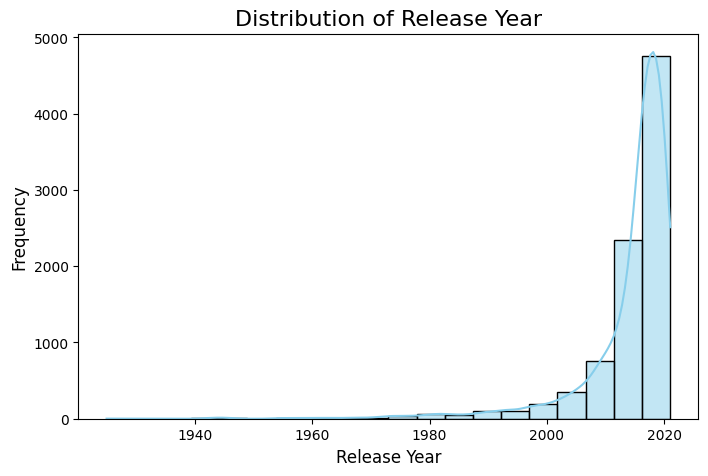

In [ ]:
#4.1
import seaborn as sns
import matplotlib.pyplot as plt

# Distplot for 'release_year'
plt.figure(figsize=(8, 5))
sns.histplot(netflix_data['release_year'], kde=True, bins=20, color='skyblue')
plt.title("Distribution of Release Year", fontsize=16)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()


In [ ]:
#4.1.1 plot for movies and tv shows

# Split the 'duration' column into separate columns for analysis
movies_duration = netflix_data[netflix_data['type'] == 'Movie'].copy()
tv_shows_duration = netflix_data[netflix_data['type'] == 'TV Show'].copy()

# Extract the numeric values from the 'duration' column
movies_duration['duration'] = movies_duration['duration'].str.replace(' min', '').astype(float)
tv_shows_duration['duration'] = tv_shows_duration['duration'].str.extract('(\d+)').astype(float)




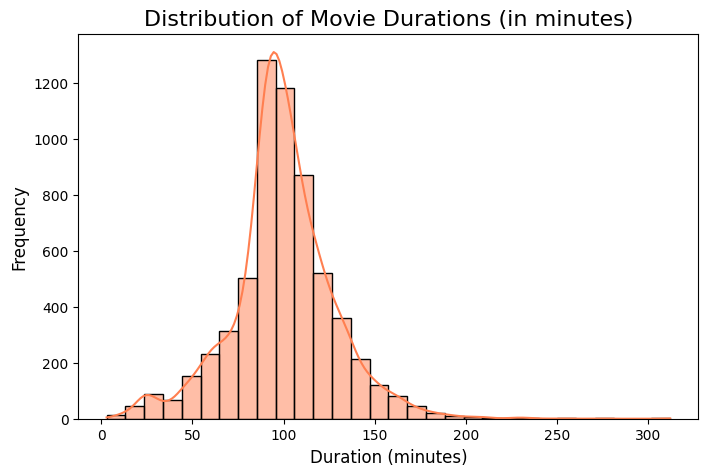

In [ ]:
# Distplot for Movie Durations (in minutes)
plt.figure(figsize=(8, 5))
sns.histplot(movies_duration['duration'], kde=True, bins=30, color='coral')
plt.title("Distribution of Movie Durations (in minutes)", fontsize=16)
plt.xlabel("Duration (minutes)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.show()


<ipython-input-51-d350a9dbc7a0>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tv_shows_duration, x='duration', palette='coolwarm')


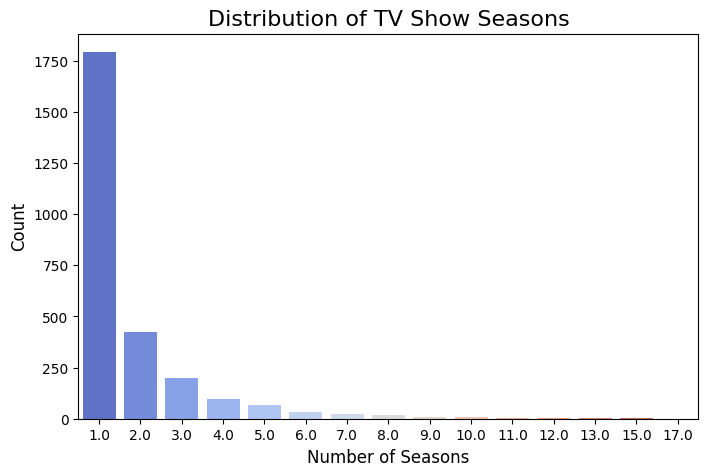

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=tv_shows_duration, x='duration', palette='coolwarm')
plt.title("Distribution of TV Show Seasons", fontsize=16)
plt.xlabel("Number of Seasons", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.show()

<ipython-input-52-e72ee9fae59e>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=netflix_data, x='rating', y='release_year', palette='coolwarm')


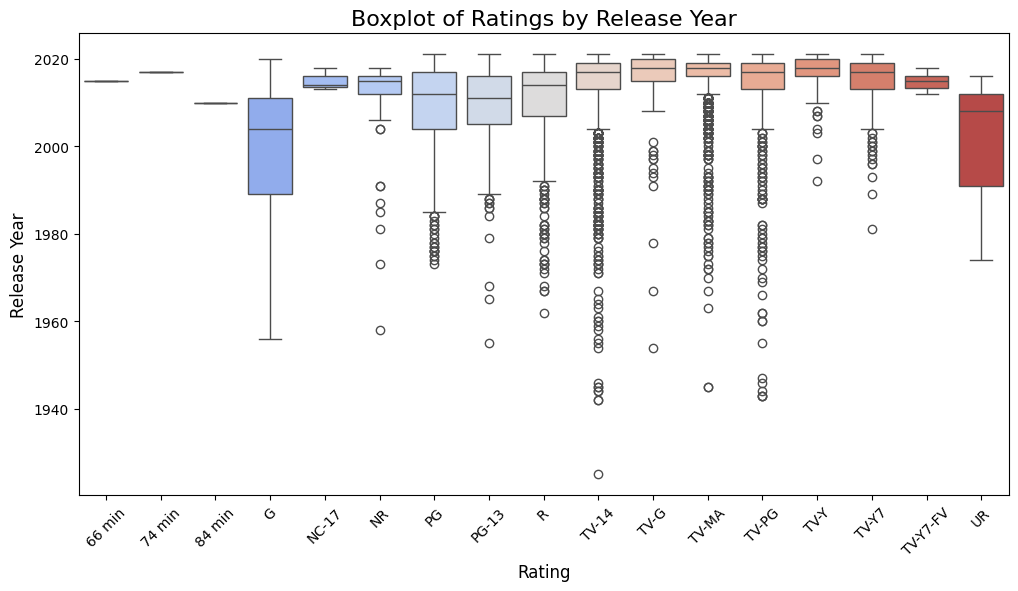

<ipython-input-52-e72ee9fae59e>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=netflix_data, x='type', y='release_year', palette='Set3')


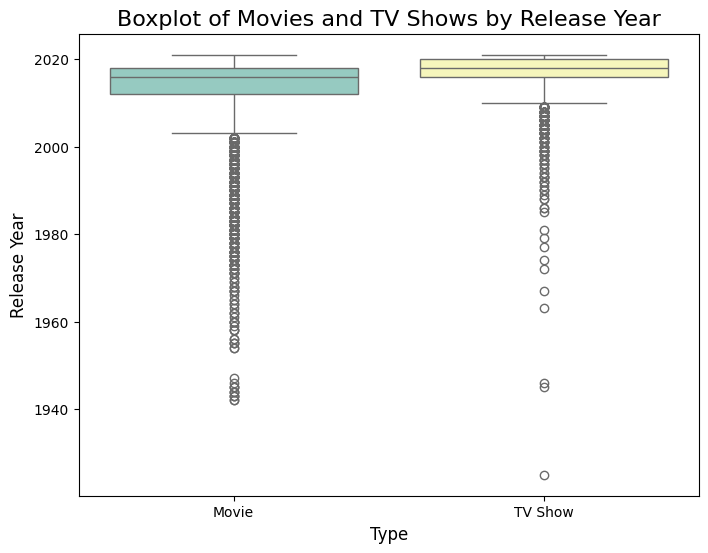

In [ ]:
4.2# Boxplot for 'rating' and 'release_year'
plt.figure(figsize=(12, 6))
sns.boxplot(data=netflix_data, x='rating', y='release_year', palette='coolwarm')
plt.title("Boxplot of Ratings by Release Year", fontsize=16)
plt.xlabel("Rating", fontsize=12)
plt.ylabel("Release Year", fontsize=12)
plt.xticks(rotation=45)
plt.show()

# Boxplot for 'type' and 'release_year'
plt.figure(figsize=(8, 6))
sns.boxplot(data=netflix_data, x='type', y='release_year', palette='Set3')
plt.title("Boxplot of Movies and TV Shows by Release Year", fontsize=16)
plt.xlabel("Type", fontsize=12)
plt.ylabel("Release Year", fontsize=12)
plt.show()

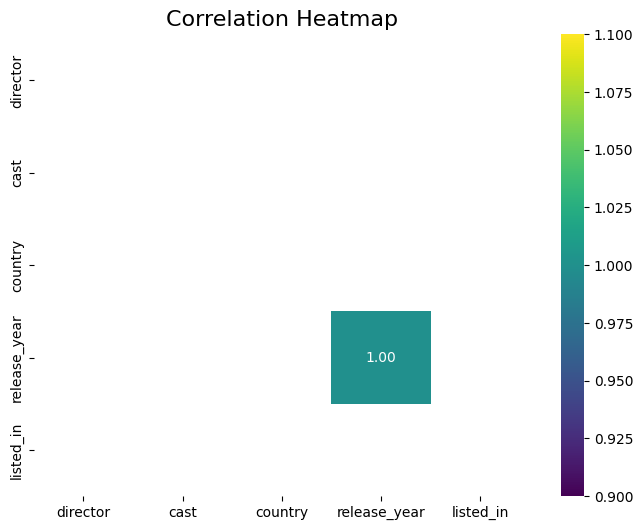

In [ ]:
#4.3 Correlation Heatmap
plt.figure(figsize=(8, 6))
correlation_matrix = netflix_data.select_dtypes(include=['int64', 'float64']).corr()
sns.heatmap(correlation_matrix, annot=True, cmap='viridis', fmt='.2f')
plt.title("Correlation Heatmap", fontsize=16)
plt.show()



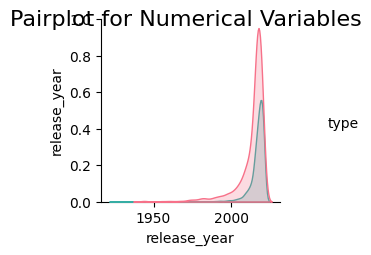

In [ ]:
# Pairplot for Release Year and Type
sns.pairplot(data=netflix_data, hue='type', palette='husl', vars=['release_year'])
plt.suptitle("Pairplot for Numerical Variables", fontsize=16)
plt.show()

Missing Value Check:
              Missing Values  Percentage
director                2634   29.908028
country                  831    9.435676
cast                     825    9.367549
date_added                10    0.113546
rating                     4    0.045418
duration                   3    0.034064
show_id                    0    0.000000
type                       0    0.000000
title                      0    0.000000
release_year               0    0.000000
listed_in                  0    0.000000
description                0    0.000000


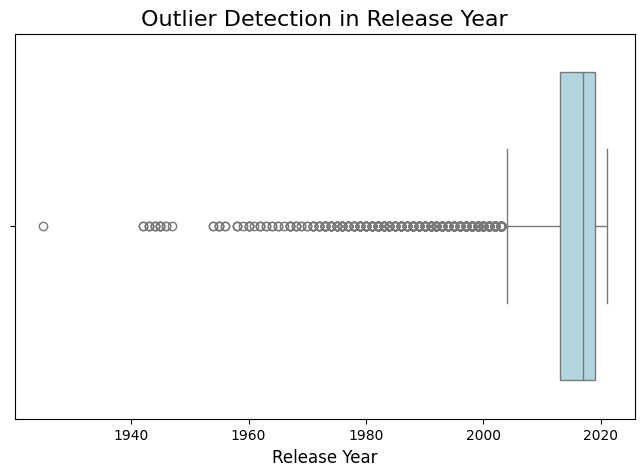

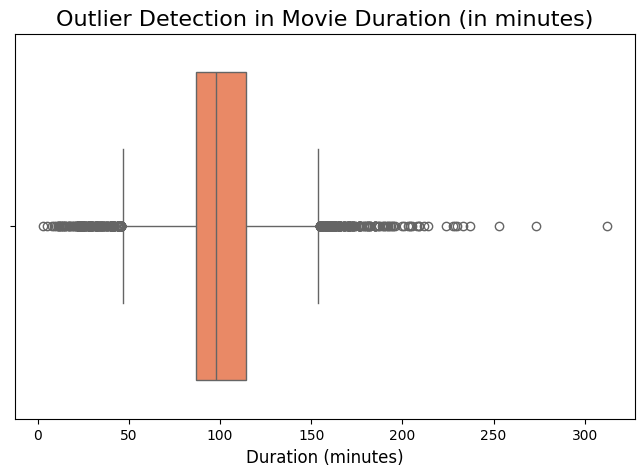

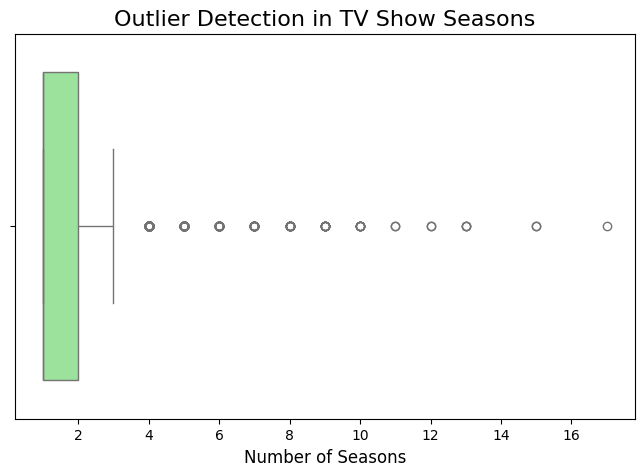

,Missing Values,Percentage
director,2634,29.908028
country,831,9.435676
cast,825,9.367549
date_added,10,0.113546
rating,4,0.045418
duration,3,0.034064
show_id,0,0.000000
type,0,0.000000
title,0,0.000000
release_year,0,0.000000


In [ ]:
#5. Missing Value & Outlier check

file_url = 'https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv'
netflix_data = pd.read_csv(file_url)

# Separate Movies and TV Shows for outlier checks on duration
movies_duration = netflix_data[netflix_data['type'] == 'Movie'].copy()
movies_duration['duration'] = pd.to_numeric(movies_duration['duration'].str.replace(' min', ''), errors='coerce')

tv_shows_duration = netflix_data[netflix_data['type'] == 'TV Show'].copy()
tv_shows_duration['duration'] = pd.to_numeric(tv_shows_duration['duration'].str.replace(' Season', '').str.replace('s', ''), errors='coerce')

# 1. Missing Value Check
missing_values = netflix_data.isnull().sum()
missing_percentage = (missing_values / len(netflix_data)) * 100
missing_data_summary = pd.DataFrame({
    'Missing Values': missing_values,
    'Percentage': missing_percentage
}).sort_values(by='Missing Values', ascending=False)

print("Missing Value Check:")
print(missing_data_summary)


# 2. Outlier Detection
# Boxplot for release_year
plt.figure(figsize=(8, 5))
sns.boxplot(x=netflix_data['release_year'], color='lightblue')
plt.title("Outlier Detection in Release Year", fontsize=16)
plt.xlabel("Release Year", fontsize=12)
plt.show()

# Boxplot for movie duration
plt.figure(figsize=(8, 5))
sns.boxplot(x=movies_duration['duration'], color='coral')
plt.title("Outlier Detection in Movie Duration (in minutes)", fontsize=16)
plt.xlabel("Duration (minutes)", fontsize=12)
plt.show()

# Boxplot for TV show seasons
plt.figure(figsize=(8, 5))
sns.boxplot(x=tv_shows_duration['duration'], color='lightgreen')
plt.title("Outlier Detection in TV Show Seasons", fontsize=16)
plt.xlabel("Number of Seasons", fontsize=12)
plt.show()

missing_data_summary


In [ ]:
#finding the top 3 genres by top 10 countries
movie_data = netflix_data[netflix_data['type'] == 'Movie']
top_countries = movie_data['country'].value_counts().head(10).index
top_country_movies = movie_data[movie_data['country'].isin(top_countries)]
listed_in_by_country = (
    top_country_movies.groupby(['country', 'listed_in'])
    .size()
    .reset_index(name='count')
)
listed_in_by_country = listed_in_by_country.sort_values(by=['count', 'country'], ascending=[False, True])
top_listed_in_by_country = listed_in_by_country.groupby('country').head(3)
print("Top 3 'Genres' by top 10 Countries:")
print(top_listed_in_by_country)


Top 3 'Genres' by top 10 Countries:
            country                                          listed_in  count
427   United States                                      Documentaries    249
483   United States                                    Stand-Up Comedy    209
102           India             Comedies, Dramas, International Movies    120
120           India                       Dramas, International Movies    118
119           India   Dramas, Independent Movies, International Movies    108
349   United States                 Children & Family Movies, Comedies     90
268  United Kingdom                                      Documentaries     40
158           Japan  Action & Adventure, Anime Features, Internatio...     32
61            Egypt                     Comedies, International Movies     29
233          Turkey                     Comedies, International Movies     23
152       Indonesia      Dramas, International Movies, Romantic Movies     21
191         Nigeria         

In [ ]:
#finding the top 3 movie ratings by top 10 countries
movie_data = netflix_data[netflix_data['type'] == 'Movie']
top_countries = movie_data['country'].value_counts().head(10).index
top_country_movies = movie_data[movie_data['country'].isin(top_countries)]
rating_by_country = (
    top_country_movies.groupby(['country', 'rating'])
    .size()
    .reset_index(name='count')
)
rating_by_country = rating_by_country.sort_values(by=['count', 'country'], ascending=[False, True])
top_ratings_by_country = rating_by_country.groupby('country').head(3)
print("Top 3 Ratings by top 10 Countries:")
print(top_ratings_by_country)


Top 3 Ratings by top 10 Countries:
           country rating  count
75   United States  TV-MA    613
20           India  TV-14    526
72   United States      R    440
71   United States  PG-13    289
22           India  TV-MA    215
23           India  TV-PG    124
60  United Kingdom  TV-MA     87
46           Spain  TV-MA     81
12           Egypt  TV-14     61
52          Turkey  TV-MA     44
8           Canada  TV-MA     42
39         Nigeria  TV-14     40
40         Nigeria  TV-MA     36
27       Indonesia  TV-14     33
57  United Kingdom      R     33
58  United Kingdom  TV-14     31
14           Egypt  TV-MA     26
34           Japan  TV-MA     24
50          Turkey  TV-14     23
35           Japan  TV-PG     21
30       Indonesia  TV-PG     20
33           Japan  TV-14     20
5           Canada      R     16
9           Canada  TV-PG     15
29       Indonesia  TV-MA     14
41         Nigeria  TV-PG      9
45           Spain  TV-14      9
53          Turkey  TV-PG      7
15      